In [5]:
import os
import warnings
os.environ["OMP_NUM_THREADS"] = "2"
warnings.filterwarnings("ignore")

Social Network Ads: {0: 160, 1: 123, 2: 117}


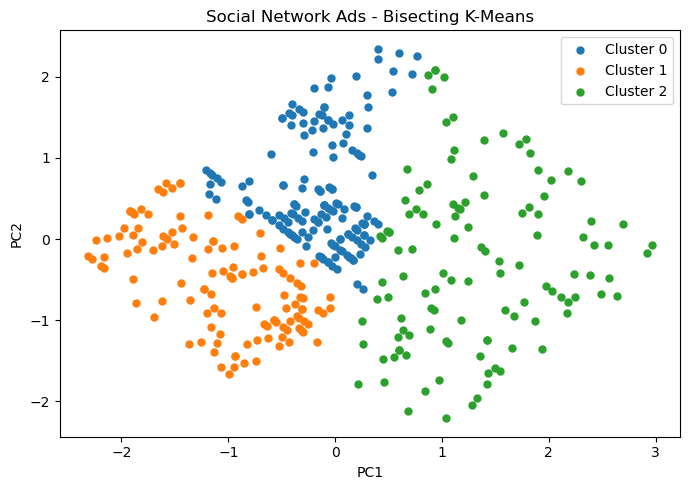

Titanic: {0: 146, 1: 224, 2: 521}


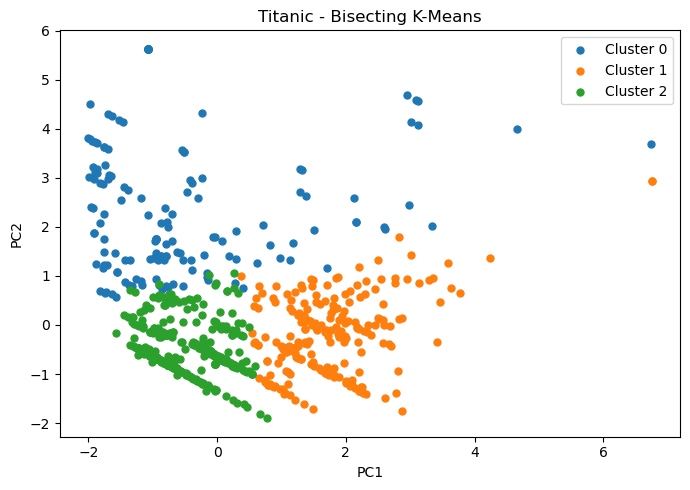

Diabetes: {0: 204, 1: 113, 2: 451}


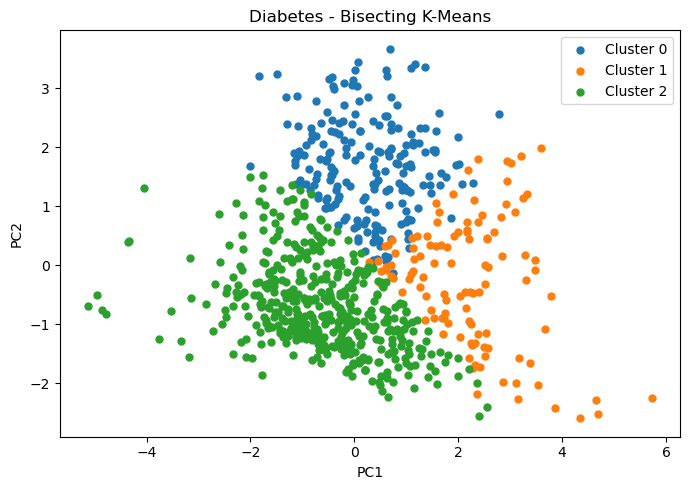

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import BisectingKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

datasets = [
    ("Social Network Ads",
     pd.read_csv("Social_Network_Ads.csv"),
     ['Age', 'EstimatedSalary']),

    ("Titanic",
     pd.read_csv("titanic.csv"),
     ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']),

    ("Diabetes",
     pd.read_csv("diabetes_dataset.csv"),
     ['Pregnancies','Glucose','BloodPressure','SkinThickness',
      'Insulin','BMI','DiabetesPedigreeFunction','Age'])
]

for name, df, features in datasets:

    X = df[features]
    X = SimpleImputer().fit_transform(X)
    X = StandardScaler().fit_transform(X)

    labels = BisectingKMeans(
        n_clusters=3,
        random_state=42
    ).fit_predict(X)

    X2d = PCA(n_components=2).fit_transform(X)

    print(f"{name}: {dict(zip(*np.unique(labels, return_counts=True)))}")

    plt.figure(figsize=(7,5))

    for c in np.unique(labels):
        plt.scatter(
            X2d[labels == c, 0],
            X2d[labels == c, 1],
            s=25,
            label=f'Cluster {c}'
        )

    plt.title(f"{name} - Bisecting K-Means")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()